# 📊 Plotting for Machine Learning — Class Notes

Complete notes for the plotting lecture. Every plot here answers **one question**, and the
answer changes what you do next in the ML pipeline.

**Files needed in the same folder as this notebook:** `Titanic-Dataset.csv`, `mpg.csv`

| columns | called | plots covered |
|---|---|---|
| 1 | univariate | `histplot` · `countplot` |
| 2 | bivariate | `boxplot` · `scatterplot` · `hue=` |
| 3+ | multivariate | `pairplot` · `heatmap` |

Demo dataset: **Titanic** (891 rows). Practice dataset: **mpg** (398 cars, 1970–82).

---
## 0️⃣ Setup

In [1]:
# run once, only if the libraries are not already installed
# !pip3 install matplotlib
# !pip3 install seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# one theme line for the whole notebook: grid background, dark high-contrast colours
sns.set_theme(style="whitegrid", palette="dark", font_scale=1.05)

df   = pd.read_csv('Titanic-Dataset.csv')   # demo
temp = pd.read_csv('mpg.csv')               # practice

print(df.shape, temp.shape)

(891, 12) (398, 9)


`sns.set_theme()` is optional. It sets the background, the grid and the colour palette once
so you do not repeat styling on every plot. Without it seaborn uses its default light
palette — the code and the meaning of every plot stay exactly the same.

In [3]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [4]:
temp.head(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite


### Why plot at all

On the Data Cleaning day you found `Fare` has mean **32.20** and median **14.45**, and you
filled the blanks with the median because the mean looked wrong.

A plot shows that decision in one picture instead of two numbers.

---
## 1️⃣ The matplotlib skeleton

Seaborn draws the plot. Matplotlib holds the canvas around it. Three lines wrap every plot
you will write:

```python
plt.figure(figsize=(7, 4))   # canvas size in inches (width, height)
sns.something(...)           # the plot itself
plt.title('...')             # label it
plt.show()                   # render and clear the canvas
```

| line | what it does | skip it and? |
|---|---|---|
| `plt.figure(figsize=(w, h))` | opens a canvas of that size | you get seaborn's default 6.4 × 4.8 |
| `sns.<plot>(data=, x=, y=)` | draws on the current canvas | nothing to see |
| `plt.title('...')` | adds a heading | untitled plot |
| `plt.xlabel` / `plt.ylabel` | override the axis names | column names are used |
| `plt.grid()` | turns the grid on | already on if you used `set_theme(style="whitegrid")` |
| `plt.show()` | renders, then **empties** the canvas | in a notebook it still shows, but plots can stack on one canvas |

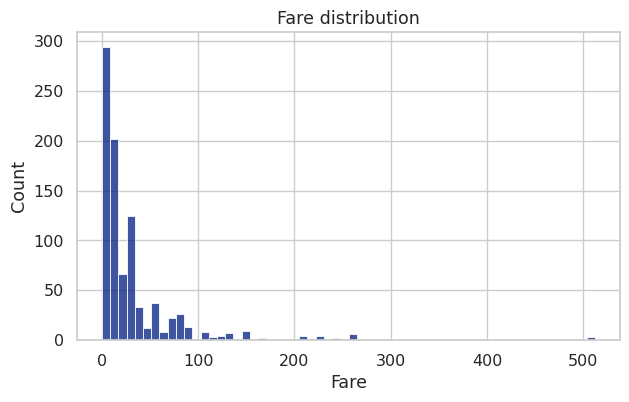

In [5]:
# the skeleton, end to end
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='Fare')
plt.title('Fare distribution')
plt.show()

### Saving a plot to a file

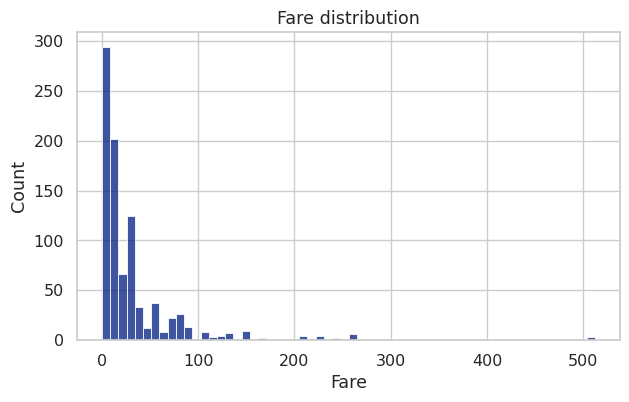

In [6]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='Fare')
plt.title('Fare distribution')
plt.savefig('fare.png', dpi=150, bbox_inches='tight')   # BEFORE show
plt.show()

⚠️ `plt.savefig()` must come **before** `plt.show()`. `show()` empties the canvas, so a
`savefig` after it writes a blank image.

| argument | effect |
|---|---|
| `dpi=150` | resolution — higher for slides or print |
| `bbox_inches='tight'` | trims the white border, stops titles getting cut off |

---
# 2️⃣ Univariate — one column at a time

**The question:** can I use this feature at all?

## `histplot` — how is one number spread out?

```python
sns.histplot(data=df, x='column', bins=25)
```

| argument | what it does |
|---|---|
| `x=` | the numeric column to spread along the horizontal axis |
| `bins=` | how many bars the range is cut into — more bins, finer detail |
| `kde=True` | draws a smooth curve over the bars |
| `hue=` | one coloured histogram per category |

The bar height is the **count of rows** falling in that bin.

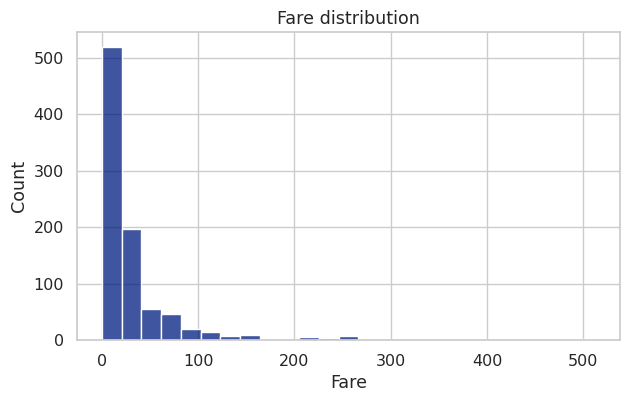

In [7]:
# distribution of Fare
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='Fare', bins=25)
plt.title('Fare distribution')
plt.show()

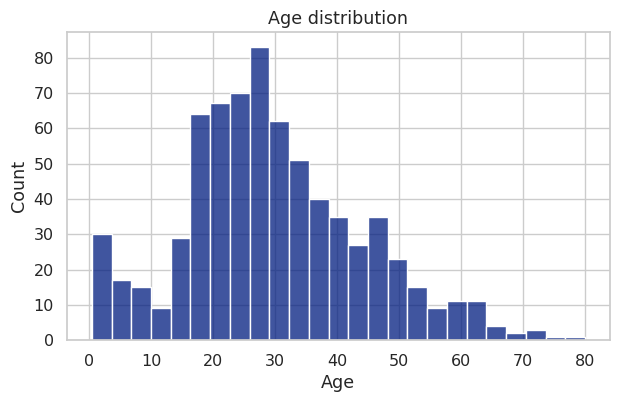

In [8]:
# distribution of Age
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='Age', bins=25)
plt.title('Age distribution')
plt.show()

In [9]:
# the numbers behind the two shapes
df[['Fare', 'Age']].agg(['mean', 'median', 'max']).round(2)

,Fare,Age
mean,32.20,29.7
median,14.45,28.0
max,512.33,80.0


| | mean | median | max |
|---|---|---|---|
| `Fare` | 32.20 | **14.45** | 512.33 |
| `Age` | 29.70 | 28.00 | 80.00 |

`Fare` has a long tail to the right — a few passengers paid enormous amounts and pulled the
mean far above the median. `Age` is roughly symmetric, so its mean and median almost match.

⭐ **The shape decides your fill value.** Long tail → fill with the median. Symmetric →
either works.

### Reading skew off a histogram

| shape | name | mean vs median | fill blanks with |
|---|---|---|---|
| tail stretches right | right / positive skew | mean **>** median | median |
| both sides equal | symmetric | mean ≈ median | mean or median |
| tail stretches left | left / negative skew | mean **<** median | median |

## `countplot` — how many rows in each category?

```python
sns.countplot(data=df, x='column')
```

| argument | what it does |
|---|---|
| `x=` | category on the horizontal axis (bars stand up) |
| `y=` | category on the vertical axis — use this when labels are long |
| `hue=` | splits each bar by a second category |
| `order=` | fixes the bar order, e.g. `order=df['Pclass'].value_counts().index` |

`countplot` counts rows for you. There is no `y` value to supply — the height **is** the count.

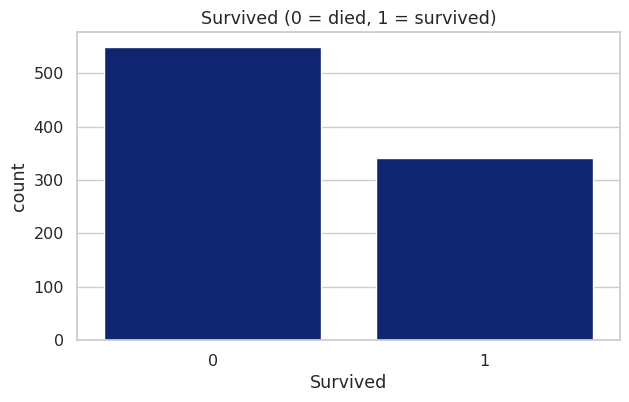

In [10]:
# how many survived and how many died
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Survived')
plt.title('Survived (0 = died, 1 = survived)')
plt.show()

In [11]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

**549 died, 342 survived** → 549 / 891 = **61.6%**.

⭐ A model that always predicts "died" scores 61.6% without learning anything. That number
is your **baseline** — any accuracy below it is worse than saying nothing. This is why you
plot the target before you build a model.

### 🧩 Practice — on `mpg.csv`

**Q1** Plot the distribution of `mpg`. Is it skewed? If this column had blanks, would you
fill with the mean or the median?

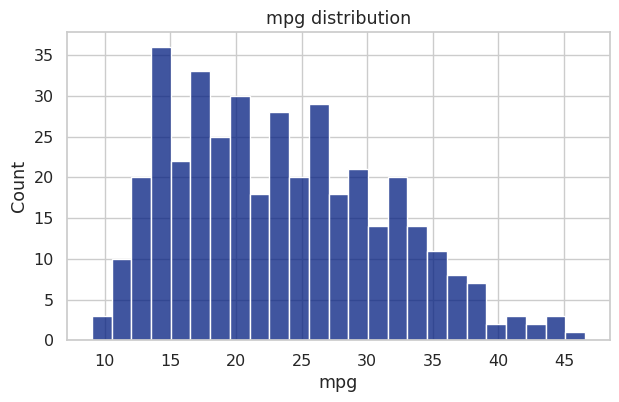

mean      23.51
median    23.00
Name: mpg, dtype: float64


In [12]:
# Q1
plt.figure(figsize=(7, 4))
sns.histplot(data=temp, x='mpg', bins=25)
plt.title('mpg distribution')
plt.show()

print(temp['mpg'].agg(['mean', 'median']).round(2))

**Answer.** Mean **23.51**, median **23.00** — a mild right skew, nothing like `Fare`.
Either fill works here, but the median is still the safer default because it does not move
when a few high-mileage cars are added.

**Q2** How many cars come from each `origin`? What would that imbalance do to a model
trained on this data?

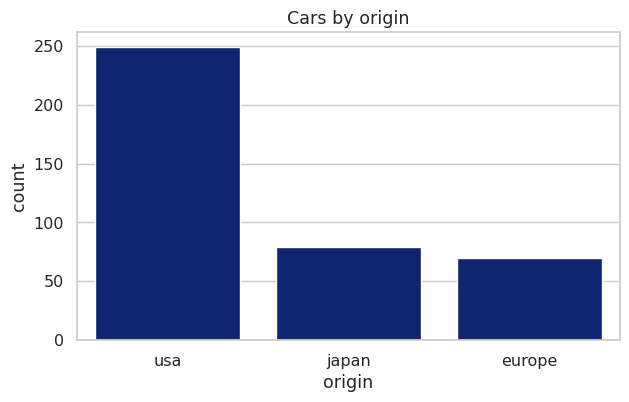

origin
usa       249
japan      79
europe     70
Name: count, dtype: int64


In [13]:
# Q2
plt.figure(figsize=(7, 4))
sns.countplot(data=temp, x='origin')
plt.title('Cars by origin')
plt.show()

print(temp['origin'].value_counts())

**Answer.** usa **249**, japan **79**, europe **70** — 62.6% of the rows are American cars.
A model predicting `origin` would reach 62.6% by always answering "usa", and it sees three
times fewer Japanese and European cars, so it learns their patterns far less well.

---
# 3️⃣ Bivariate — two columns together

**The question:** does this feature separate the thing I am predicting?

## `boxplot` — does a number differ across groups?

```python
sns.boxplot(data=df, x='category', y='number')
```

Anatomy of one box:

| part | meaning |
|---|---|
| bottom of box | Q1 — 25% of values are below it |
| line inside box | **median** (Q2) |
| top of box | Q3 — 75% of values are below it |
| box height | IQR = Q3 − Q1, the middle half of the data |
| whiskers | reach to the furthest point within 1.5 × IQR of the box |
| dots beyond whiskers | **outliers** by the 1.5 × IQR rule |

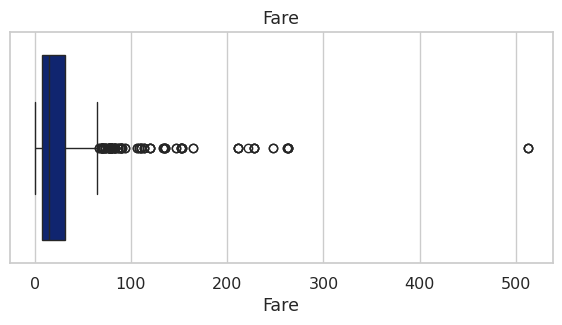

In [14]:
# Fare on its own — read the box, the whiskers, the dots
plt.figure(figsize=(7, 3))
sns.boxplot(data=df, x='Fare')
plt.title('Fare')
plt.show()

In [15]:
# the same 1.5 x IQR rule, in numbers
q1, q3 = df['Fare'].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df[(df['Fare'] < low) | (df['Fare'] > high)]

print('Q1', q1, '| Q3', q3, '| IQR', round(iqr, 2))
print('whiskers stop at', round(low, 2), 'and', round(high, 2))
print('outliers:', len(outliers))

Q1 7.9104 | Q3 31.0 | IQR 23.09
whiskers stop at -26.72 and 65.63
outliers: 116


`Fare` has **116** outliers — every dot to the right of the whisker. A boxplot finds them
visually; the quantile calculation above is the same rule written out.

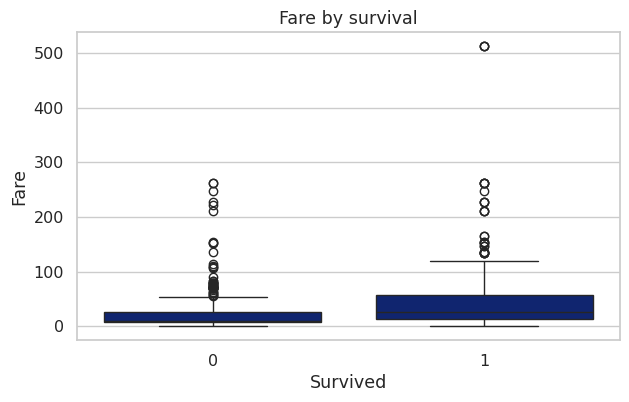

In [16]:
# Fare split by Survived
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Survived', y='Fare')
plt.title('Fare by survival')
plt.show()

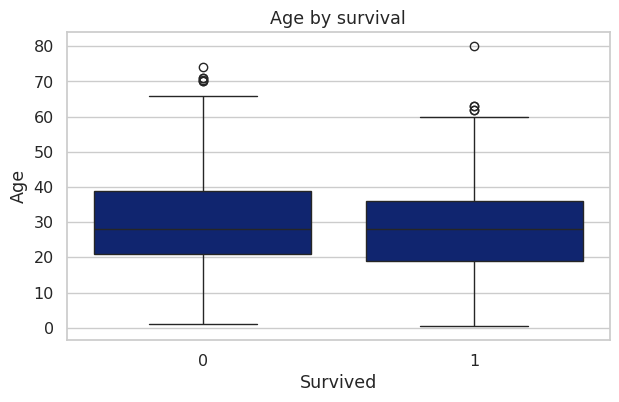

In [17]:
# Age split by Survived
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Survived', y='Age')
plt.title('Age by survival')
plt.show()

In [18]:
df.groupby('Survived')[['Fare', 'Age']].median()

,Fare,Age
Survived,,
0,10.5,28.0
1,26.0,28.0


| | died | survived |
|---|---|---|
| median `Fare` | 10.50 | **26.00** |
| median `Age` | 28.0 | 28.0 |

⭐ `Fare` separates the two groups — the boxes barely overlap. `Age` does not — the two
boxes sit on top of each other. **A feature that does not separate your classes will not
help your model.**

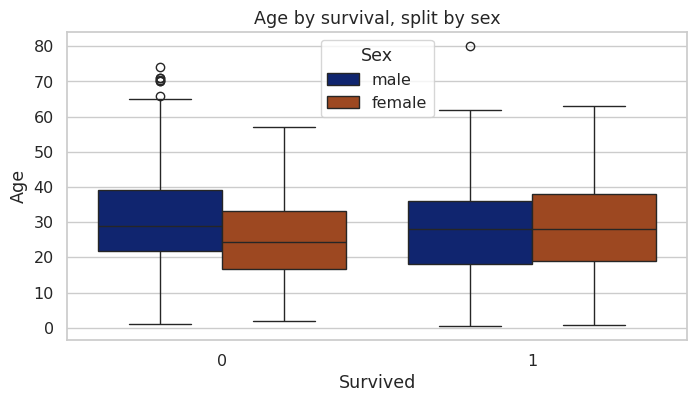

In [19]:
# a third column inside the same boxplot, using hue
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Survived', y='Age', hue='Sex')
plt.title('Age by survival, split by sex')
plt.show()

`Age` alone does not separate survivors — but split by `Sex`, the surviving group holds
noticeably younger males. A feature can be useless on its own and useful in combination.

## `scatterplot` — do two numbers move together?

```python
sns.scatterplot(data=df, x='number1', y='number2')
```

| argument | what it does |
|---|---|
| `x=`, `y=` | the two numeric columns — one dot per row |
| `hue=` | colours the dots by a third column |
| `size=` | sizes the dots by a fourth column |
| `alpha=` | transparency 0–1, use it when dots pile up |

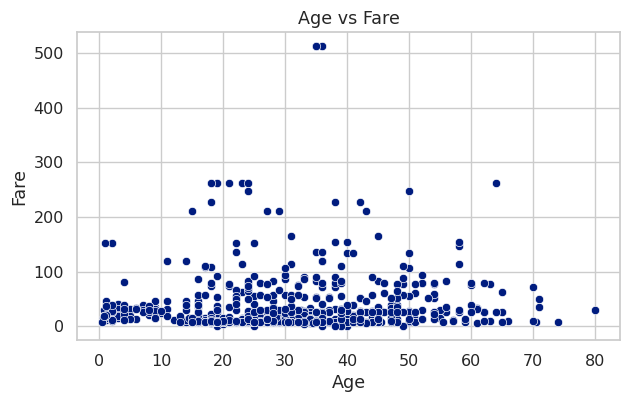

correlation: 0.096


In [20]:
# Age against Fare
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x='Age', y='Fare')
plt.title('Age vs Fare')
plt.show()

print('correlation:', round(df['Age'].corr(df['Fare']), 3))

A shapeless cloud, correlation **0.096**. These two columns barely relate.

| what the cloud looks like | what it means |
|---|---|
| rises left to right | positive relationship |
| falls left to right | negative relationship |
| shapeless blob | no linear relationship |
| tight line | very strong relationship — check for duplicate features |

## `hue=` — the argument that turns any plot into an ML plot

Add one word and the target column appears inside the picture. `hue=` works on `histplot`,
`countplot`, `boxplot`, `scatterplot` and `pairplot` — the same argument everywhere.

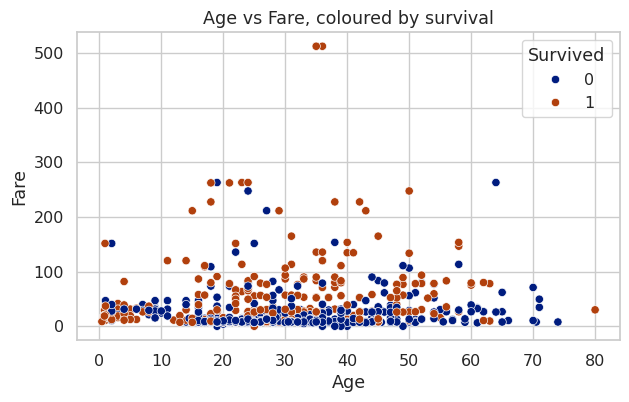

In [21]:
# the same scatter, coloured by Survived
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived')
plt.title('Age vs Fare, coloured by survival')
plt.show()

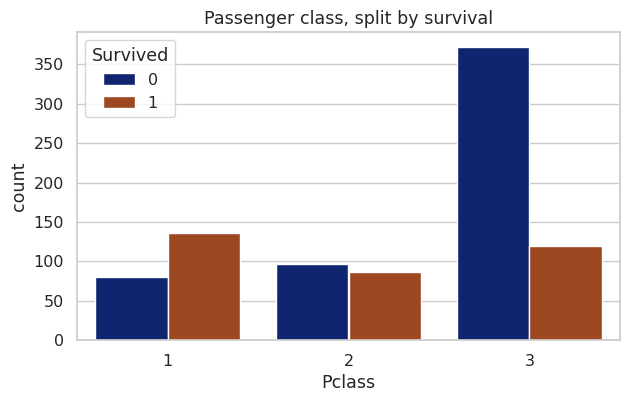

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [22]:
# a countplot of Pclass, coloured by Survived
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Passenger class, split by survival')
plt.show()

print(df['Pclass'].value_counts())

The scatter now shows *where* the survivors sit — the high-fare band is almost all orange.
The countplot shows the survival split **and** the group sizes at once: class 1 = 216,
class 2 = 184, class 3 = **491**.

⭐ That is the "read the group size next to the group average" rule, drawn instead of
calculated. A 40% survival rate inside a 20-row group means much less than the same rate
inside a 491-row group.

### 🧩 Practice — on `mpg.csv`

**Q3** Boxplot `mpg` split by `origin`, then split by `cylinders` instead.
Which of the two separates the groups more clearly?

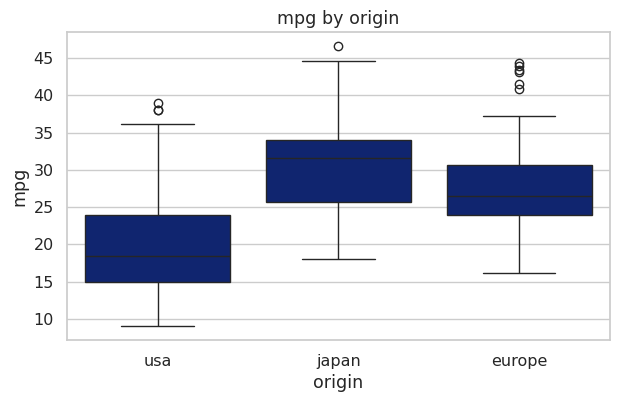

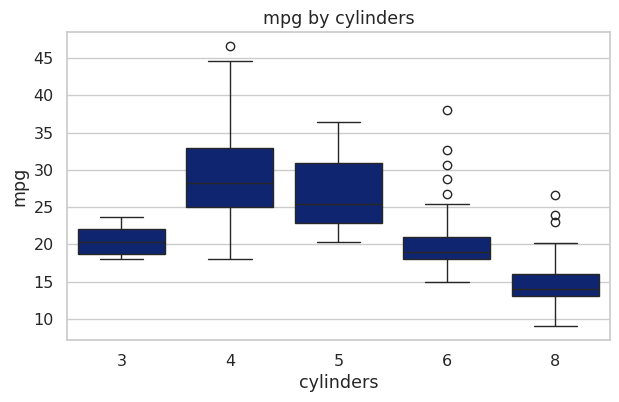

origin
europe    26.5
japan     31.6
usa       18.5
Name: mpg, dtype: float64
cylinders
3    20.25
4    28.25
5    25.40
6    19.00
8    14.00
Name: mpg, dtype: float64


In [23]:
# Q3
plt.figure(figsize=(7, 4))
sns.boxplot(data=temp, x='origin', y='mpg')
plt.title('mpg by origin')
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(data=temp, x='cylinders', y='mpg')
plt.title('mpg by cylinders')
plt.show()

print(temp.groupby('origin')['mpg'].median())
print(temp.groupby('cylinders')['mpg'].median())

**Answer.** `origin` medians run 18.5 (usa) → 26.5 (europe) → 31.6 (japan), and the boxes
overlap. `cylinders` medians run 28.25 (4 cyl) → 19.0 (6 cyl) → 14.0 (8 cyl), and those
boxes barely touch. **`cylinders` separates more cleanly**, so it is the stronger feature
for predicting `mpg`.

**Q4** Scatter `weight` against `mpg`, coloured by `origin`.
Describe the relationship in one line, and say what the colours add.

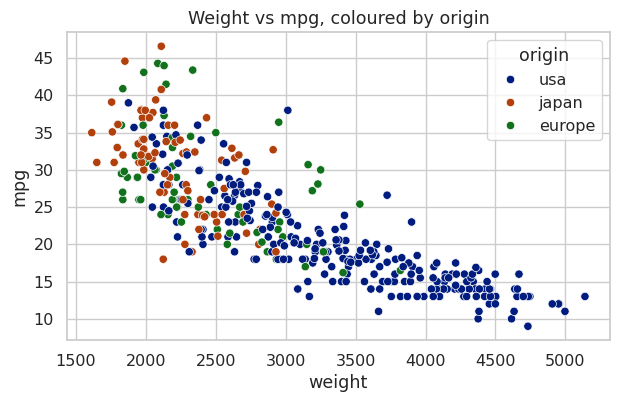

correlation: -0.832


In [24]:
# Q4
plt.figure(figsize=(7, 4))
sns.scatterplot(data=temp, x='weight', y='mpg', hue='origin')
plt.title('Weight vs mpg, coloured by origin')
plt.show()

print('correlation:', round(temp['weight'].corr(temp['mpg']), 3))

**Answer.** A clear downward cloud — heavier cars give lower mileage, correlation
**−0.832**. The colours add the reason: American cars sit in the heavy, low-mileage corner
while Japanese and European cars cluster light and efficient. `origin` and `weight` are
partly telling the same story.

---
# 4️⃣ Multivariate — everything at once

**The question:** which features matter, and which ones repeat each other?

## `pairplot` — every pair of columns in one grid

```python
sns.pairplot(df[['col1', 'col2', 'col3']], hue='target')
```

| argument | what it does |
|---|---|
| `vars=` | which columns to include (instead of slicing the DataFrame) |
| `hue=` | colours every panel by a category |
| `diag_kind=` | `'hist'` or `'kde'` — what sits on the diagonal |
| `height=` | size of **each** panel in inches |
| `corner=True` | drops the mirror-image upper half |

⚠️ `pairplot` builds its own figure, so `plt.figure(figsize=...)` has no effect on it. Use
`height=`. It is also slow and unreadable on wide tables — pick your columns first.

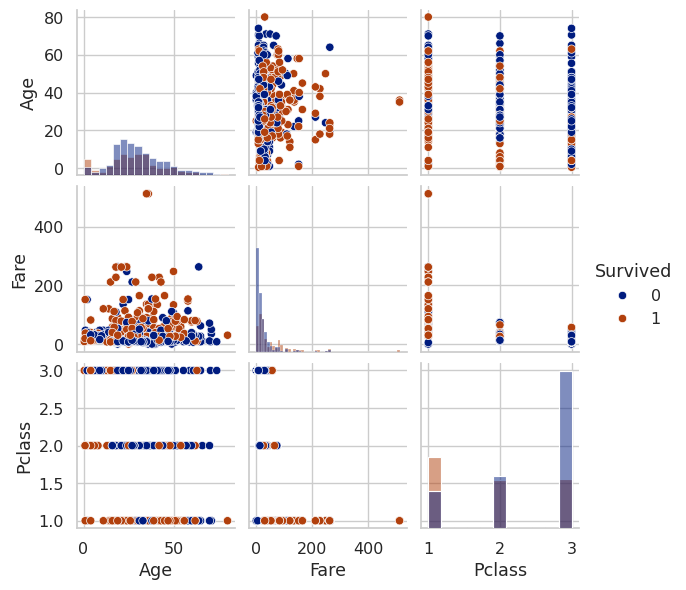

In [25]:
# pairplot of Age, Fare and Pclass, coloured by Survived
sns.pairplot(df[['Age', 'Fare', 'Pclass', 'Survived']].dropna(),
             hue='Survived', diag_kind='hist', height=2)
plt.show()

Scatter plots off the diagonal, distributions along it. Every univariate and bivariate plot
from today, in a single line of code — this is the plot you run first on a new dataset.

## `heatmap` — the same idea, as numbers

```python
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu_r')
```

`df.corr()` gives a correlation matrix: every numeric column against every other, from
**−1** (perfect opposite) through **0** (no relationship) to **+1** (identical movement).
`numeric_only=True` skips the text columns, which cannot be correlated.

| argument | what it does |
|---|---|
| `annot=True` | writes the number inside each cell |
| `cmap=` | colour scale — `'RdBu_r'`, `'coolwarm'`, `'viridis'` |
| `fmt='.2f'` | decimal places on the annotations |
| `vmin=-1, vmax=1` | fixes the colour scale so plots are comparable |
| `linewidths=` | gap between cells |

In [26]:
# correlation of the numeric columns
df.corr(numeric_only=True).round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.00,-0.01,-0.04,0.04,-0.06,-0.00,0.01
Survived,-0.01,1.00,-0.34,-0.08,-0.04,0.08,0.26
Pclass,-0.04,-0.34,1.00,-0.37,0.08,0.02,-0.55
Age,0.04,-0.08,-0.37,1.00,-0.31,-0.19,0.10
SibSp,-0.06,-0.04,0.08,-0.31,1.00,0.41,0.16
Parch,-0.00,0.08,0.02,-0.19,0.41,1.00,0.22
Fare,0.01,0.26,-0.55,0.10,0.16,0.22,1.00


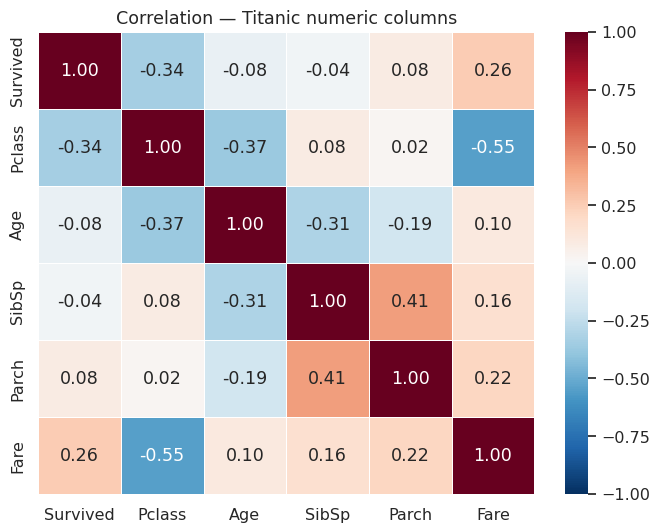

In [27]:
# the same thing as a heatmap, with the numbers written on it
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(columns='PassengerId').corr(numeric_only=True),
            annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation — Titanic numeric columns')
plt.show()

Correlation with `Survived`:

| feature | correlation |
|---|---|
| `Pclass` | **−0.34** |
| `Fare` | 0.26 |
| `Parch` | 0.08 |
| `Age` | −0.08 |
| `SibSp` | −0.04 |

The `Pclass` value is negative because class 1 is the *best* class — a lower number means a
higher survival chance. Sign tells you direction; the size tells you strength.

⭐ A heatmap does two jobs at once:
1. read the **target row** → which features predict what you care about
2. read the **rest of the grid** → which features are duplicates of each other (two features
   above ~0.9 carry the same information, so one can be dropped)

### 🧩 Practice — on `mpg.csv`

**Q5** ⭐ Heatmap of the numeric columns in `mpg`. Two parts:

1. Which feature predicts `mpg` best?
2. Find two features that are almost the same thing — if you had to drop one, which and why?

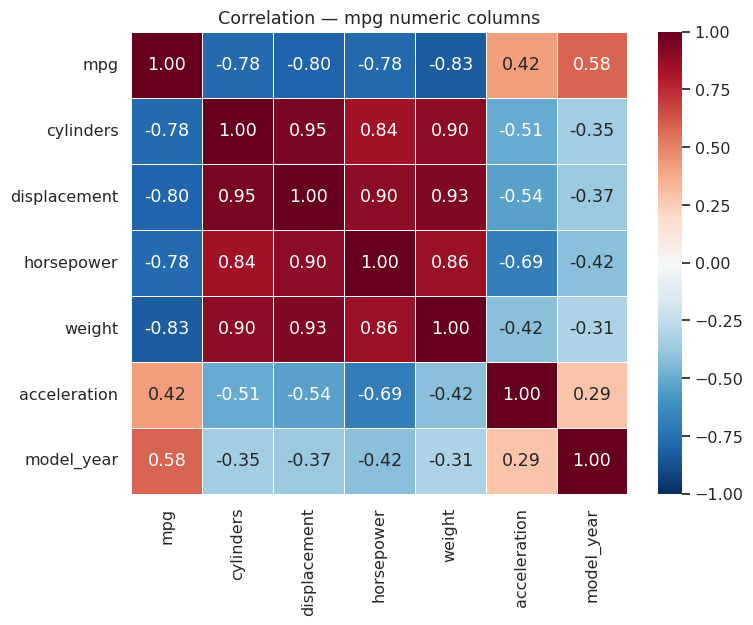

In [28]:
# Q5
plt.figure(figsize=(8, 6))
sns.heatmap(temp.corr(numeric_only=True),
            annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation — mpg numeric columns')
plt.show()

**Answer.**

1. **`weight`, at −0.832** — the strongest single predictor of `mpg`. `displacement`
   (−0.804), `horsepower` (−0.778) and `cylinders` (−0.775) follow closely.
2. **`cylinders` and `displacement` correlate 0.95** — engine size measured two ways.
   `displacement` and `weight` are close behind at 0.93. Drop `cylinders`: it holds the
   same information as `displacement` but in only 5 distinct steps, so it is the coarser of
   the two.

---
# 📌 Quick reference

## Which plot, when

| Your question | Columns | Plot |
|---|---|---|
| How is one number spread out? | 1 numeric | `histplot` |
| How many rows in each category? | 1 categorical | `countplot` |
| Does this number differ across groups? | numeric + categorical | `boxplot` |
| Do two numbers move together? | 2 numeric | `scatterplot` |
| *…and does the target split them?* | **+ target** | **add `hue=`** |
| Quick look at everything | many numeric | `pairplot` |
| Which features matter, which repeat? | many numeric | `heatmap` |

## The skeleton

```python
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='column')
plt.title('...')
plt.show()
```

## Syntax in one place

```python
sns.histplot(data=df, x='Fare', bins=25, kde=True)
sns.countplot(data=df, x='Pclass', hue='Survived')
sns.boxplot(data=df, x='Survived', y='Fare', hue='Sex')
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', alpha=0.7)
sns.pairplot(df[['Age', 'Fare', 'Survived']], hue='Survived', diag_kind='hist', height=2)
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='RdBu_r')
plt.savefig('name.png', dpi=150, bbox_inches='tight')
```

## Common errors

| what you see | why | fix |
|---|---|---|
| saved image is blank | `savefig` written after `show` | put `savefig` before `show` |
| `could not convert string to float` on `.corr()` | text columns in the frame | `df.corr(numeric_only=True)` |
| `figsize` does nothing on a pairplot | pairplot makes its own figure | use `height=` |
| two plots land on one canvas | no `plt.show()` between them | end every plot with `show()` |
| `ValueError: Could not interpret value` | column name typo or wrong case | check `df.columns` |
| bars/dots in a wall of one colour | no `hue=` | add `hue='target'` |
| scatter is a solid black mass | too many overlapping dots | `alpha=0.3` |

## What each plot decided today

- `Fare` is right-skewed → **fill its blanks with the median**
- 61.6% died → **any model must beat 61.6% to be worth anything**
- `Fare` separates survivors, `Age` does not → **keep `Fare`, question `Age`**
- `Pclass` correlates −0.34 with survival → **the strongest single number available**
- `cylinders` and `displacement` correlate 0.95 in mpg → **keep one, drop the other**